In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (make_scorer,mean_squared_error, mean_absolute_error, 
                            r2_score, explained_variance_score)

In [2]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_V2.csv')

X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
def gap_scorer(estimator, X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    test_r2_scores = []
    gaps = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        estimator.fit(X_train_fold, y_train_fold)
        train_r2 = r2_score(y_train_fold, estimator.predict(X_train_fold))
        val_r2 = r2_score(y_val, estimator.predict(X_val))
        
        test_r2_scores.append(val_r2)
        gaps.append(abs(train_r2 - val_r2))
    
    # 80% weight on test R2, 20% penalty for gaps
    return (0.8 * np.mean(test_r2_scores)) - (0.2 * np.mean(gaps))

In [4]:
def gap_scorer_mae(estimator, X, y):
    """
    Custom scorer that:
    1) Evaluates MAE (lower is better)
    2) Penalizes the gap between train/val MAE
    3) Returns a composite score where lower is better
    
    Returns: 
        (0.8 * mean_val_mae) + (0.2 * mean_mae_gap)
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    val_mae_scores = []
    mae_gaps = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        estimator.fit(X_train_fold, y_train_fold)
        
        # Calculate MAEs
        train_mae = mean_absolute_error(y_train_fold, estimator.predict(X_train_fold))
        val_mae = mean_absolute_error(y_val, estimator.predict(X_val))
        
        val_mae_scores.append(val_mae)
        mae_gaps.append(abs(train_mae - val_mae))
    
    # Composite score (lower is better)
    return (0.8 * np.mean(val_mae_scores)) + (0.2 * np.mean(mae_gaps))


# For GridSearchCV (needs to be a scorer where higher=better)
mae_gap_scorer = make_scorer(
    lambda e, X, y: -gap_scorer_mae(e, X, y),  # Invert since lower MAE is better
    greater_is_better=True
)

In [5]:
param_grid = {
    'regressor__max_depth': [10, 15, 20],  # Added None for unlimited depth
    'regressor__min_samples_split': [2, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 2, 4, 8],
    'regressor__max_features': ['sqrt', 'log2', None, 0.5, 0.75], # Added numerical fractions
    'regressor__criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'], # Added more criteria
    'regressor__splitter': ['best', 'random'], # How to choose the split at each node
    'regressor__max_leaf_nodes': [None, 10, 20, 50, 100] # Limit the number of leaf nodes
}

In [6]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [7]:
pipeline = Pipeline(steps=[
    ('preprocessor', numeric_transformer),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

In [ ]:
import time
from sklearn.model_selection import GridSearchCV

# Start timer
start_time = time.time()

grid_search = GridSearchCV(
    estimator=pipeline,
    scoring=gap_scorer,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)

# Calculate and print elapsed time
elapsed = time.time() - start_time
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nTotal training time: {int(hours):0>2}h {int(minutes):0>2}m {seconds:05.2f}s")

Fitting 5 folds for each of 9600 candidates, totalling 48000 fits


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
print(f"\nBest parameters: {grid_search.best_params_}")


In [ ]:
def calculate_metrics(model, X_train, X_test, y_train, y_test):
    """Calculate and print all regression metrics"""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Explained Variance': explained_variance_score(y_test, y_pred_test),
        'Train-Test R² Gap': abs(r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test))
    }
    
    return pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

metrics_df = calculate_metrics(best_model, X_train, X_test, y_train, y_test)
print(metrics_df)

                         Value
Train R²              0.951126
Test R²               0.819906
Train RMSE          419.692133
Test RMSE           784.840984
Train MAE           240.154105
Test MAE            440.922025
Explained Variance    0.820298
Train-Test R² Gap     0.131220


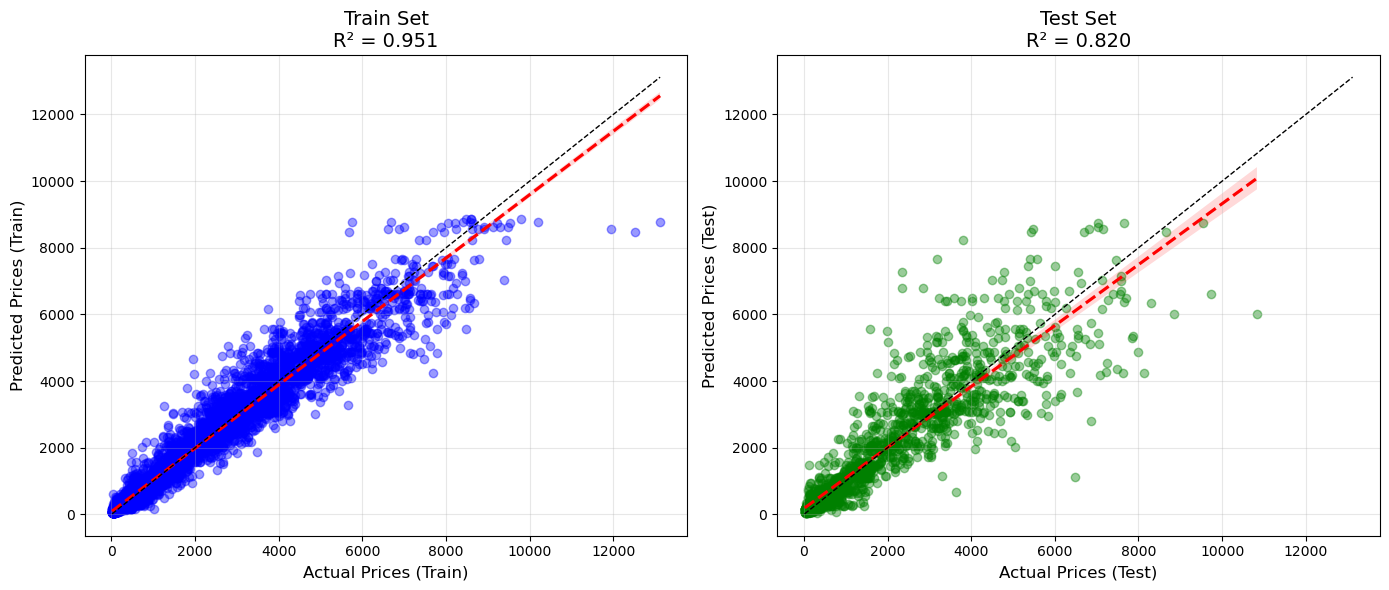

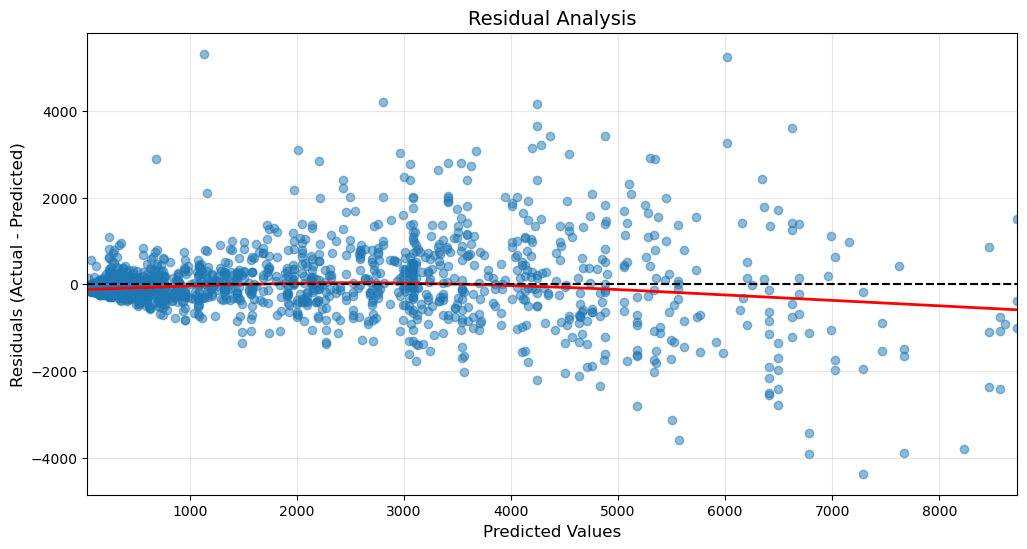

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Create figure with two subplots
plt.figure(figsize=(14, 6))

# Subplot 1: Training set results
plt.subplot(1, 2, 1)
sns.regplot(x=y_train, y=y_train_pred, 
            scatter_kws={'alpha':0.4, 'color':'blue'},
            line_kws={'color':'red', 'linestyle':'--'})
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1)
plt.xlabel('Actual Prices (Train)', fontsize=12)
plt.ylabel('Predicted Prices (Train)', fontsize=12)
plt.title(f'Train Set\nR² = {r2_score(y_train, y_train_pred):.3f}', fontsize=14)
plt.grid(alpha=0.3)

# Subplot 2: Test set results
plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_test_pred, 
            scatter_kws={'alpha':0.4, 'color':'green'},
            line_kws={'color':'red', 'linestyle':'--'})
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1)
plt.xlabel('Actual Prices (Test)', fontsize=12)
plt.ylabel('Predicted Prices (Test)', fontsize=12)
plt.title(f'Test Set\nR² = {r2_score(y_test, y_test_pred):.3f}', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(12, 6))
residuals = y_test - y_test_pred
sns.residplot(x=y_test_pred, y=residuals, 
              lowess=True,
              scatter_kws={'alpha':0.5},
              line_kws={'color':'red', 'lw':2})
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Analysis', fontsize=14)
plt.grid(alpha=0.3)
plt.show()